# D10 + Lapa EEC subset: Motilin exploration

Working with the 819-cell CellAssign-subset EEC data.
Current labels: `granular_EEC_label_v3` (X, D, I, K, Enterochromaffin, Early EECs).

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.sparse import issparse
import matplotlib.pyplot as plt

import sys
from pathlib import Path

_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

from src.config import ANALYSIS_DIR, FIGURES_DIR

In [2]:
# Load the 819-cell EEC subset (v3 labels with kNN refinement)
adata = sc.read_h5ad(ANALYSIS_DIR / "manual_labelled_2" / "knn_EECs_egfDuod_D10_Lapa_DZ.h5ad")
print(adata)
print()
print(adata.obs["granular_EEC_label_v3"].value_counts())

AnnData object with n_obs × n_vars = 819 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'size_factor', 'initial_cellassign_prediction', 'leiden_subcluster', 'EEC_label', 'granular_EEC_label', 'granular_EEC_label_v2', 'pred_graph', 'conf_graph', 'granular_EEC_label_v3'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'EEC_label_colors', 'X_name', 'granular_EEC_label_colors', 'granular_EEC_label_v2_colors', 'granular_EEC_label_v3_colors', 'hvg', 'initial_cellassign_prediction_colors', 'leiden_colors', 'leiden_subcluster', 'leiden_subcluster_colors', 'log1p', 'neighbors', 'pca', 'pred_graph_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

granular_EEC_label_v3
Enterochromaffin cells    404
D cells 

In [3]:
# MLN isn't in the 3000-HVG knn object, but IS in the full 28k-gene dataset.
# Pull MLN expression from the full counts layer for our 819 barcodes.
adata_full = sc.read_h5ad(ANALYSIS_DIR / "cellassign_objects" / "d10_lapa_predictions.h5ad")

# Get MLN counts for our 819 EEC barcodes
shared = adata.obs_names.intersection(adata_full.obs_names)
print(f"819 EEC barcodes found in full dataset: {len(shared)}")

mln_full = adata_full[shared, "MLN"].layers["counts"]
if issparse(mln_full):
    mln_full = mln_full.toarray()
mln_counts = pd.Series(np.ravel(mln_full), index=shared, name="MLN_counts")

# Normalize the same way as the EEC object (target_sum=1e4, log1p)
import scipy.sparse as sp
total_counts_full = np.asarray(adata_full[shared].layers["counts"].sum(axis=1)).ravel()
mln_norm = np.log1p(mln_counts.values / total_counts_full * 1e4)
mln_norm_series = pd.Series(mln_norm, index=shared, name="MLN_norm")

# Add to our EEC adata
adata.obs["MLN_expr"] = mln_norm_series.reindex(adata.obs_names).fillna(0).values
print(f"\nMLN expression stats (log-normalized):")
print(f"  % positive: {(adata.obs['MLN_expr'] > 0).mean()*100:.1f}%")
print(f"  mean: {adata.obs['MLN_expr'].mean():.3f}")
print(f"  max:  {adata.obs['MLN_expr'].max():.3f}")

819 EEC barcodes found in full dataset: 819

MLN expression stats (log-normalized):
  % positive: 0.0%
  mean: 0.000
  max:  0.000


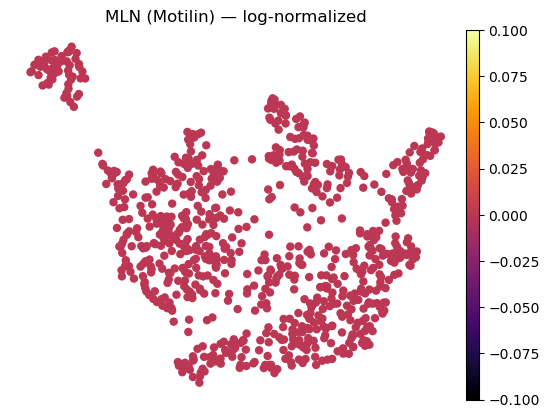

In [4]:
# Plot MLN expression on UMAP (using obs column since gene not in var_names)
sc.pl.umap(
    adata,
    color="MLN_expr",
    cmap="inferno",
    vmax="p95",
    frameon=False,
    title="MLN (Motilin) — log-normalized"
)

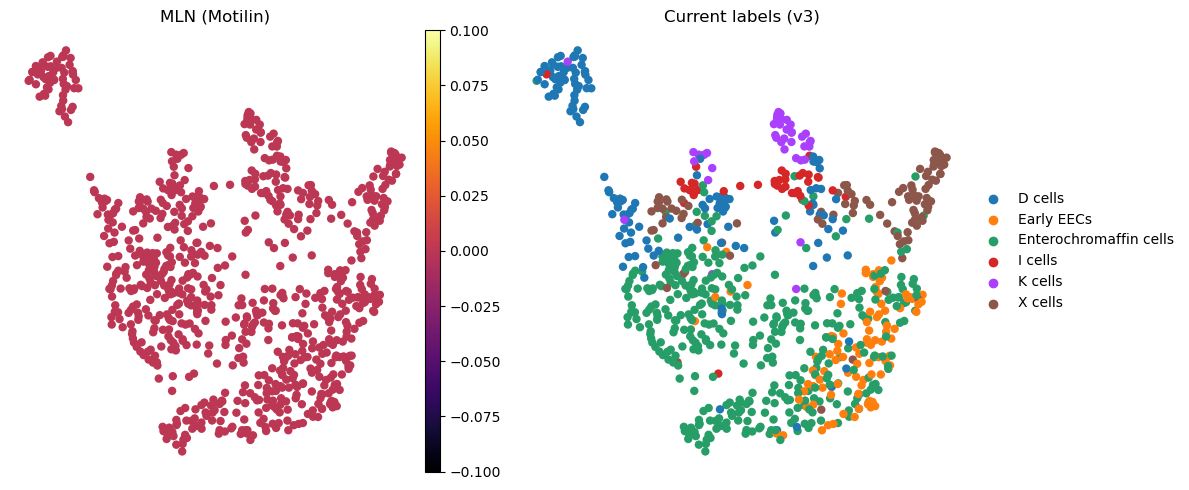

In [5]:
# Side-by-side: MLN expression + current labels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc.pl.umap(adata, color="MLN_expr", cmap="inferno", vmax="p95",
           frameon=False, title="MLN (Motilin)", show=False, ax=axes[0])
sc.pl.umap(adata, color="granular_EEC_label_v3",
           palette=sc.pl.palettes.default_20,
           frameon=False, title="Current labels (v3)", show=False, ax=axes[1])
plt.tight_layout()
plt.show()

In [6]:
# Quantify MLN expression per current label
for label in sorted(adata.obs["granular_EEC_label_v3"].unique()):
    mask = adata.obs["granular_EEC_label_v3"] == label
    vals = adata.obs.loc[mask, "MLN_expr"].values
    pct_pos = (vals > 0).mean() * 100
    print(f"{label:30s}  n={mask.sum():4d}  %MLN+={pct_pos:5.1f}%  mean={vals.mean():.3f}  max={vals.max():.3f}")

D cells                         n= 142  %MLN+=  0.0%  mean=0.000  max=0.000
Early EECs                      n=  95  %MLN+=  0.0%  mean=0.000  max=0.000
Enterochromaffin cells          n= 404  %MLN+=  0.0%  mean=0.000  max=0.000
I cells                         n=  38  %MLN+=  0.0%  mean=0.000  max=0.000
K cells                         n=  40  %MLN+=  0.0%  mean=0.000  max=0.000
X cells                         n= 100  %MLN+=  0.0%  mean=0.000  max=0.000


### Result: MLN is not expressed in this dataset

Across all 33,507 cells in D10+Lapa, only **4 cells** have any MLN counts at all (17 total counts, 14 in one cell). None of those 4 cells are in our 819 EEC subset.

For comparison, other peptide hormones are well-detected:
| Gene | Total counts | Cells >0 |
|------|-------------|----------|
| MLN  | 17          | 4        |
| GHRL | 4,154       | 432      |
| SST  | 78,544      | 1,338    |
| CCK  | 2,175       | 152      |
| GIP  | 1,786       | 83       |

**Conclusion**: Cannot label M cells — motilin is not expressed at detectable levels in these organoid EECs.

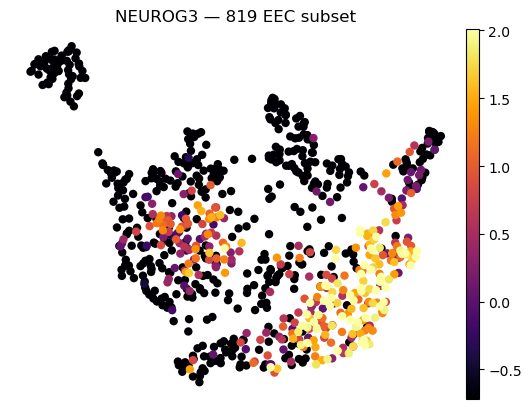

In [7]:
sc.pl.umap(
    adata,
    color="NEUROG3",
    cmap="inferno",
    vmax="p95",
    frameon=False,
    title="NEUROG3 — 819 EEC subset"
)